<a href="https://colab.research.google.com/github/Chandan2403maity/Chandan-Maity_24-14-16/blob/main/Rainfall_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Loading: /content/Rainfall_Data.csv
Initial shape: (366, 12)
Columns:
 ['day', 'pressure', 'maxtemp', 'temparature', 'mintemp', 'dewpoint', 'humidity', 'cloud', 'rainfall', 'sunshine', 'winddirection', 'windspeed']
Engineered features added: []
Detected target column: rainfall
Dropped 0 rows with missing target. Remaining rows: 366
Feature shape: (366, 11) Target shape: (366,)
Sample target distribution:
 rainfall
1    0.680328
0    0.319672
Name: proportion, dtype: float64
Categorical columns to encode: []

Before SMOTE class counts:
 rainfall
1    249
0    117
Name: count, dtype: int64
Applying SMOTE to balance classes...
After SMOTE class counts:
 rainfall
1    249
0    249
Name: count, dtype: int64
Train shape: (373, 11) Test shape: (125, 11)
Training CatBoost (this may take ~30s-3min depending on data size)...
0:	learn: 0.8257373	total: 9.2ms	remaining: 8.27s
200:	learn: 0.9892761	total: 1.25s	remaining: 4.35s
400:	learn: 1.0000000	total: 2.53s	remaining: 3.15s
600:	learn: 1.00000

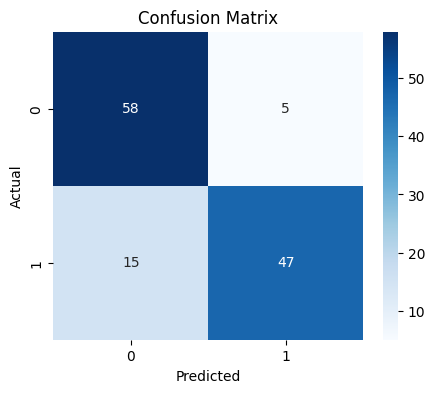


Sample features (first test row):
    day  pressure  maxtemp  temparature  mintemp  dewpoint  humidity  cloud  \
1    2    1022.0     21.7         18.9     17.2      15.6        81     83   

   sunshine  winddirection  windspeed  
1       0.6           50.0       15.3  
Predicted label for sample: 1


In [5]:
# =======================================================
# ROBUST HIGH-ACCURACY RAINFALL PIPELINE (FIXED KEYERROR)
# Feature engineering only if source columns exist + SMOTE + CatBoost
# Paste into Google Colab and run
# =======================================================

!pip install -q catboost imbalanced-learn

import os
import pandas as pd
import numpy as np
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from catboost import CatBoostClassifier
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# ---------------------------
# 1) LOAD DATA (try /content then upload)
# ---------------------------
path = "/content/Rainfall_Data.csv"
if not os.path.exists(path):
    print("File /content/Rainfall_Data.csv not found — please upload the file now.")
    uploaded = files.upload()  # user selects file; it will be placed in /content
    # pick the first uploaded file name
    path = list(uploaded.keys())[0]

print("Loading:", path)
df = pd.read_csv(path)
print("Initial shape:", df.shape)
print("Columns:\n", df.columns.tolist())

# ---------------------------
# Helper: check existence of columns
# ---------------------------
def has_cols(df, cols):
    return all([c in df.columns for c in cols])

# ---------------------------
# 2) FEATURE ENGINEERING (only when source columns exist)
# ---------------------------
engineered = []
# DewPoint approx: needs Humidity3pm and Temp3pm
if has_cols(df, ["Humidity3pm", "Temp3pm"]):
    df["DewPoint"] = (df["Humidity3pm"] / 100.0) * df["Temp3pm"]
    engineered.append("DewPoint")

# PressureDrop = Pressure9am - Pressure3pm
if has_cols(df, ["Pressure9am", "Pressure3pm"]):
    df["PressureDrop"] = df["Pressure9am"] - df["Pressure3pm"]
    engineered.append("PressureDrop")

# TempChange = Temp3pm - Temp9am
if has_cols(df, ["Temp3pm", "Temp9am"]):
    df["TempChange"] = df["Temp3pm"] - df["Temp9am"]
    engineered.append("TempChange")

# HumidityDiff = Humidity3pm - Humidity9am
if has_cols(df, ["Humidity3pm", "Humidity9am"]):
    df["HumidityDiff"] = df["Humidity3pm"] - df["Humidity9am"]
    engineered.append("HumidityDiff")

# WindAvg = average of wind speeds
if has_cols(df, ["WindSpeed9am", "WindSpeed3pm"]):
    df["WindAvg"] = (df["WindSpeed9am"].fillna(0) + df["WindSpeed3pm"].fillna(0)) / 2
    engineered.append("WindAvg")

# If Date exists, extract Year/Month/Day
if "Date" in df.columns:
    try:
        df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
        df["Year"] = df["Date"].dt.year
        df["Month"] = df["Date"].dt.month
        df["Day"] = df["Date"].dt.day
        df = df.drop(columns=["Date"])
        engineered += ["Year", "Month", "Day"]
    except Exception:
        pass

print("Engineered features added:", engineered)

# ---------------------------
# 3) TARGET DETECTION & CLEANING
# ---------------------------
possible_targets = ["RainTomorrow", "rainfall", "Rainfall", "Rain"]
target = None
for t in possible_targets:
    if t in df.columns:
        target = t
        break

if target is None:
    raise ValueError("Target column not found. Ensure one of these columns exists: " + ", ".join(possible_targets))

print("Detected target column:", target)

# Some datasets use 'Yes'/'No' strings — convert to 1/0
if df[target].dtype == object or df[target].dtype.name == "category":
    df[target] = df[target].astype(str).str.strip().str.lower()
    # map common variants
    mapping = {"yes":1, "y":1, "true":1, "1":1, "no":0, "n":0, "false":0, "0":0}
    df[target] = df[target].map(mapping).astype(float)
    # if mapping created NaNs (unmapped strings), try numeric conversion
    if df[target].isna().any():
        df[target] = pd.to_numeric(df[target], errors='coerce')

# Drop rows where target is still missing
before_rows = df.shape[0]
df = df.dropna(subset=[target])
print(f"Dropped {before_rows - df.shape[0]} rows with missing target. Remaining rows: {df.shape[0]}")

# ---------------------------
# 4) MISSING VALUES
# ---------------------------
# Fill numeric columns with median
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Exclude target from fill of features
num_features = [c for c in num_cols if c != target]
df[num_features] = df[num_features].fillna(df[num_features].median())

# Fill categorical/object columns with mode
for col in df.select_dtypes(include=['object','category']).columns:
    if col == target:
        continue
    df[col] = df[col].fillna(df[col].mode().iloc[0] if not df[col].mode().empty else "")

# ---------------------------
# 5) PREPARE X and y
# ---------------------------
X = df.drop(columns=[target])
y = df[target].astype(int)

print("Feature shape:", X.shape, "Target shape:", y.shape)
print("Sample target distribution:\n", y.value_counts(normalize=True))

# ---------------------------
# 6) ENCODE CATEGORICAL FEATURES
# ---------------------------
cat_cols = X.select_dtypes(include=['object','category']).columns.tolist()
print("Categorical columns to encode:", cat_cols)

le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    le_dict[col] = le

# Ensure all features are numeric now
assert X.select_dtypes(exclude=[np.number]).shape[1] == 0, "Non-numeric features remain"

# ---------------------------
# 7) OPTIONAL: SMOTE if dataset is imbalanced
# ---------------------------
print("\nBefore SMOTE class counts:\n", y.value_counts())
minority_ratio = min(y.value_counts()) / max(y.value_counts())
apply_smote = (minority_ratio < 0.7)  # heuristic: if minority <70% of majority, apply SMOTE

if apply_smote:
    print("Applying SMOTE to balance classes...")
    sm = SMOTE(random_state=42)
    X_res, y_res = sm.fit_resample(X, y)
    print("After SMOTE class counts:\n", pd.Series(y_res).value_counts())
else:
    print("SMOTE skipped (classes reasonably balanced).")
    X_res, y_res = X, y

# ---------------------------
# 8) TRAIN-TEST SPLIT
# ---------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.25, random_state=42, stratify=y_res if len(np.unique(y_res))>1 else None
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

# ---------------------------
# 9) TRAIN CatBoost
# ---------------------------
model = CatBoostClassifier(
    iterations=900,
    depth=8,
    learning_rate=0.03,
    l2_leaf_reg=6,
    loss_function='Logloss',
    eval_metric='Accuracy',
    random_seed=42,
    verbose=200
)

print("Training CatBoost (this may take ~30s-3min depending on data size)...")
model.fit(X_train, y_train)

# ---------------------------
# 10) EVALUATION
# ---------------------------
y_pred = model.predict(X_test).astype(int)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix plot
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ---------------------------
# 11) EXAMPLE PREDICTION (first test row)
# ---------------------------
if X_test.shape[0] > 0:
    sample = X_test.iloc[[0]]
    print("\nSample features (first test row):\n", sample)
    print("Predicted label for sample:", model.predict(sample)[0])
else:
    print("No test rows to show predictions.")

# ---------------------------
# 12) SAVE MODEL (optional)
# ---------------------------
# model.save_model("/content/catboost_rainfall.cbm")
# print("Saved CatBoost model to /content/catboost_rainfall.cbm")

In [7]:
# =========================================================
# CatBoost + Optuna hyperparameter tuning
# Robust auto-detection of target column (no KeyError)
# =========================================================

!pip install -q catboost optuna

import os
import pandas as pd
import numpy as np
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from catboost import CatBoostClassifier, Pool
import optuna
from sklearn.preprocessing import LabelEncoder

# -----------------------------
# 1) Upload dataset (Colab)
# -----------------------------
print("Please upload your CSV file (choose Rainfall dataset).")
uploaded = files.upload()
csv_name = list(uploaded.keys())[0]
print("Uploaded:", csv_name)

df = pd.read_csv(csv_name)
print("\nData shape:", df.shape)
print("Columns:", df.columns.tolist()[:50])

# -----------------------------
# 2) Try to detect target column
# -----------------------------
possible_names = ["RainTomorrow", "rainTomorrow", "Rainfall", "rainfall", "Rain", "rain", "RainToday", "raintoday", "Rain_Tomorrow"]

def detect_target(df):
    # 1) exact name
    for name in possible_names:
        if name in df.columns:
            return name
    # 2) columns containing 'rain' substring (case-insensitive)
    rain_cols = [c for c in df.columns if 'rain' in c.lower()]
    if len(rain_cols) == 1:
        return rain_cols[0]
    if len(rain_cols) > 1:
        # prefer RainTomorrow-like columns
        for c in rain_cols:
            if 'tomorrow' in c.lower():
                return c
        return rain_cols[0]
    # 3) pick any binary (or near-binary) column (<=3 unique values and not an ID)
    candidate = None
    for c in df.columns:
        nunique = df[c].nunique(dropna=True)
        if nunique <= 3 and nunique > 1 and df[c].dtype != 'float64' and df[c].dtype != 'int64':
            return c
        if nunique <= 3 and nunique > 1:
            candidate = c
    if candidate is not None:
        return candidate
    # 4) fallback: search numeric columns with exactly 2 unique values
    for c in df.columns:
        try:
            nunique = df[c].nunique(dropna=True)
            if nunique == 2:
                return c
        except:
            continue
    return None

target = detect_target(df)
if target is None:
    raise ValueError("Could not detect target column automatically. Please rename your target column to one of: "
                     + ", ".join(possible_names) + " or ensure there is a binary column indicating rain (Yes/No or 0/1).")
print("\nDetected target column:", target)

# -----------------------------
# 3) Basic cleaning and mapping target to 0/1
# -----------------------------
# If target is string (Yes/No), map to 0/1
if df[target].dtype == object or df[target].dtype.name == 'category':
    df[target] = df[target].astype(str).str.strip().str.lower()
    mapping = {"yes":1, "y":1, "true":1, "1":1, "no":0, "n":0, "false":0, "0":0}
    df[target] = df[target].map(mapping)
    # If still contains other values, try numeric conversion
    if df[target].isna().any():
        df[target] = pd.to_numeric(df[target], errors='coerce')

# Drop rows where target is missing
before = df.shape[0]
df = df.dropna(subset=[target])
print(f"Dropped {before - df.shape[0]} rows with missing target. Remaining rows: {df.shape[0]}")

# If target still not integer-like, cast
df[target] = df[target].astype(int)

# -----------------------------
# 4) Feature engineering (safe checks)
# -----------------------------
def safe_add_feature(df, new_col, req_cols, func):
    if all([c in df.columns for c in req_cols]):
        try:
            df[new_col] = func(df)
            return True
        except Exception as e:
            return False
    return False

added = []
# example engineered features if source columns exist
if safe_add_feature(df, "DewPoint", ["Humidity3pm", "Temp3pm"], lambda d: (d["Humidity3pm"]/100.0) * d["Temp3pm"]):
    added.append("DewPoint")
if safe_add_feature(df, "PressureDrop", ["Pressure9am", "Pressure3pm"], lambda d: d["Pressure9am"] - d["Pressure3pm"]):
    added.append("PressureDrop")
if safe_add_feature(df, "TempChange", ["Temp3pm", "Temp9am"], lambda d: d["Temp3pm"] - d["Temp9am"]):
    added.append("TempChange")
if safe_add_feature(df, "HumidityDiff", ["Humidity3pm", "Humidity9am"], lambda d: d["Humidity3pm"] - d["Humidity9am"]):
    added.append("HumidityDiff")
if safe_add_feature(df, "WindAvg", ["WindSpeed9am", "WindSpeed3pm"], lambda d: (d["WindSpeed9am"].fillna(0)+d["WindSpeed3pm"].fillna(0))/2):
    added.append("WindAvg")
# Date split
if "Date" in df.columns:
    try:
        df["Date"] = pd.to_datetime(df["Date"], errors='coerce')
        df["Year"] = df["Date"].dt.year
        df["Month"] = df["Date"].dt.month
        df["Day"] = df["Date"].dt.day
        df = df.drop(columns=["Date"])
        added.extend(["Year","Month","Day"])
    except:
        pass

print("Engineered features added:", added)

# -----------------------------
# 5) Fill missing values
# -----------------------------
# Numeric: median, Categorical: mode
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_features = [c for c in num_cols if c != target]
df[num_features] = df[num_features].fillna(df[num_features].median())

for col in df.select_dtypes(include=['object','category']).columns.tolist():
    if col == target:
        continue
    mode = df[col].mode()
    if not mode.empty:
        df[col] = df[col].fillna(mode.iloc[0])
    else:
        df[col] = df[col].fillna("NA")

# -----------------------------
# 6) Prepare X, y and identify categorical features
# -----------------------------
X = df.drop(columns=[target])
y = df[target].astype(int)

# Identify categorical columns for CatBoost (by dtype object/category)
cat_feature_names = [c for c in X.columns if X[c].dtype == "object" or X[c].dtype.name == "category"]
print("Categorical features detected:", cat_feature_names)

# For safety, convert pandas categorical/object to string type (CatBoost can take names)
for c in cat_feature_names:
    X[c] = X[c].astype(str)

# If there are still object columns not intended as categorical, CatBoost will handle them as categorical strings.

# -----------------------------
# 7) Train/test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y if len(y.unique())>1 else None
)

# Build Pools for CatBoost (using column names for cat_features)
cat_features_index = [X.columns.get_loc(c) for c in cat_feature_names]  # indices required by Pool if using indices
train_pool = Pool(X_train, y_train, cat_features=cat_feature_names)
test_pool  = Pool(X_test,  y_test,  cat_features=cat_feature_names)

print("\nTrain shape:", X_train.shape, "Test shape:", X_test.shape)

# -----------------------------
# 8) Optuna objective
# -----------------------------
def objective(trial):
    params = {
        "iterations": trial.suggest_int("iterations", 200, 1200),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "depth": trial.suggest_int("depth", 4, 12),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1e-1, 10.0, log=True),
        "border_count": trial.suggest_int("border_count", 32, 255),
        "random_strength": trial.suggest_float("random_strength", 0.0, 20.0),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 10.0),
        "loss_function": "Logloss",
        "eval_metric": "Accuracy",
        "verbose": 0,
        # using CPU; change to "GPU" if you have GPU available and want faster runs
        "task_type": "CPU",
        "random_seed": 42
    }
    model = CatBoostClassifier(**params)
    model.fit(train_pool, eval_set=test_pool, verbose=False)
    preds = model.predict(X_test)
    return accuracy_score(y_test, preds)

# -----------------------------
# 9) Run Optuna study
# -----------------------------
study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=30, show_progress_bar=True)  # increase n_trials for more thorough search

print("\nBest trial accuracy:", study.best_value)
print("Best params:", study.best_params)

# -----------------------------
# 10) Train final model with best params
# -----------------------------
best_params = study.best_params
best_params.update({
    "loss_function":"Logloss",
    "eval_metric":"Accuracy",
    "random_seed":42,
    "verbose":100,
    "task_type":"CPU"
})
final_model = CatBoostClassifier(**best_params)

print("\nTraining final model with best parameters...")
final_model.fit(train_pool, eval_set=test_pool)

# -----------------------------
# 11) Evaluation
# -----------------------------
preds = final_model.predict(X_test)
print("\nFinal Accuracy:", accuracy_score(y_test, preds))
print("\nClassification Report:\n", classification_report(y_test, preds))

# -----------------------------
# 12) Quick sample prediction (first test row)
# -----------------------------
if X_test.shape[0] > 0:
    sample = X_test.iloc[[0]]
    print("\nSample features:\n", sample)
    print("Predicted label for sample:", final_model.predict(sample)[0])

Please upload your CSV file (choose Rainfall dataset).


[I 2025-12-06 14:21:43,173] A new study created in memory with name: no-name-01cb3b6a-0048-49f8-a65f-66dbb140a14e


Saving Rainfall_Data.csv to Rainfall_Data (2).csv
Uploaded: Rainfall_Data (2).csv

Data shape: (366, 12)
Columns: ['day', 'pressure', 'maxtemp', 'temparature', 'mintemp', 'dewpoint', 'humidity', 'cloud', 'rainfall', 'sunshine', 'winddirection', 'windspeed']

Detected target column: rainfall
Dropped 0 rows with missing target. Remaining rows: 366
Engineered features added: []
Categorical features detected: []

Train shape: (292, 11) Test shape: (74, 11)


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2025-12-06 14:21:47,652] Trial 0 finished with value: 0.8918918918918919 and parameters: {'iterations': 574, 'learning_rate': 0.2536999076681772, 'depth': 10, 'l2_leaf_reg': 1.5751320499779735, 'border_count': 66, 'random_strength': 3.119890406724053, 'bagging_temperature': 0.5808361216819946}. Best is trial 0 with value: 0.8918918918918919.
[I 2025-12-06 14:22:03,195] Trial 1 finished with value: 0.8378378378378378 and parameters: {'iterations': 1067, 'learning_rate': 0.07725378389307355, 'depth': 10, 'l2_leaf_reg': 0.10994335574766201, 'border_count': 249, 'random_strength': 16.648852816008436, 'bagging_temperature': 2.1233911067827616}. Best is trial 0 with value: 0.8918918918918919.
[I 2025-12-06 14:22:03,921] Trial 2 finished with value: 0.8648648648648649 and parameters: {'iterations': 382, 'learning_rate': 0.018659959624904916, 'depth': 6, 'l2_leaf_reg': 1.1207606211860568, 'border_count': 128, 'random_strength': 5.824582803960839, 'bagging_temperature': 6.118528947223795}. B